# Baseline Metrics — Simulation Validation

Quantify the simulation's output **distributions** and validate them against NYP operational benchmarks. Each section shows a distribution (across replications or across patients) rather than a single point estimate, to reveal how stable the model is and where uncertainty is highest.

| Section | What it shows | Comparison target |
|---|---|---|
| **Wait Time Distributions** | Days from patient creation to each care step | NYP scheduling data |
| **Revenue Distributions** | Realized & foregone revenue per procedure | NYP Finance / CPT contract rates |
| **Screening & LTFU Rates** | Cervical screening, abnormal, LTFU, colposcopy completion | HEDIS / NYP EHR rates |
| **Cervical Result Distribution** | Result-category mix vs. expected probabilities | ASCCP / NCI prevalence tables |
| **Lung-RADS Distribution** | RADS category mix vs. expected | ACR national data / NYP LDCT program |
| **Summary Validation Table** | All key metrics: mean ± std vs. hospital reference | NYP benchmark targets |

> All rate parameters are **placeholders**. Replace `config.py` values with NYP EHR-derived rates before using for operational planning.  
> Revenue figures use placeholder CPT rates — replace `cfg.PROCEDURE_REVENUE` with NYP contract rates.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict

import config as cfg
from runner import SimulationRunner
from metrics import compute_rates, compute_revenue

---

## Setup — Multi-Replication Run

We run `N_REPS` independent replications of a 1-year (365-day) simulation, each with a different random seed, to build up two types of data:

- **Per-patient distributions** — pooled `wait_times` lists across all reps (large sample → stable histograms)
- **Per-replication summaries** — scalar metrics (rates, revenue) from each rep, shown as box plots

Increase `N_REPS` for tighter confidence intervals; decrease it to run faster. 20 reps typically takes ~30 seconds.

In [2]:
N_REPS = 20
N_DAYS = 365

all_metrics  = []                  # one dict per replication
pooled_waits = defaultdict(list)   # resource → patient wait times (all reps pooled)

for rep in range(N_REPS):
    sim = SimulationRunner(n_days=N_DAYS, seed=cfg.RANDOM_SEED + rep)
    m   = sim.run()
    all_metrics.append(m)
    for resource, times in m['wait_times'].items():
        pooled_waits[resource].extend(times)

print(f"Completed {N_REPS} replications  ·  {N_DAYS}-day horizon each")
print(f"Total pooled wait-time observations: {sum(len(v) for v in pooled_waits.values()):,}")
print(f"Resources with wait-time data: {sorted(pooled_waits.keys())}")

Completed 20 replications  ·  365-day horizon each
Total pooled wait-time observations: 1,109,072
Resources with wait-time data: ['colposcopy', 'leep', 'screening_seen']


---

## Wait Time Distributions

Each bar below is a **patient-level observation** pooled across all replications. Long right tails signal capacity bottlenecks — patients waiting well beyond the median. The vertical lines show the median, mean, and 90th percentile.

> **Unit:** Days from patient creation to the care event (includes scheduling lead time and any queue delay).  
> **PENDING:** Replace `cfg.FOLLOWUP_DELAY_DAYS` with empirical distributions from NYP scheduling data so these match real wait times.

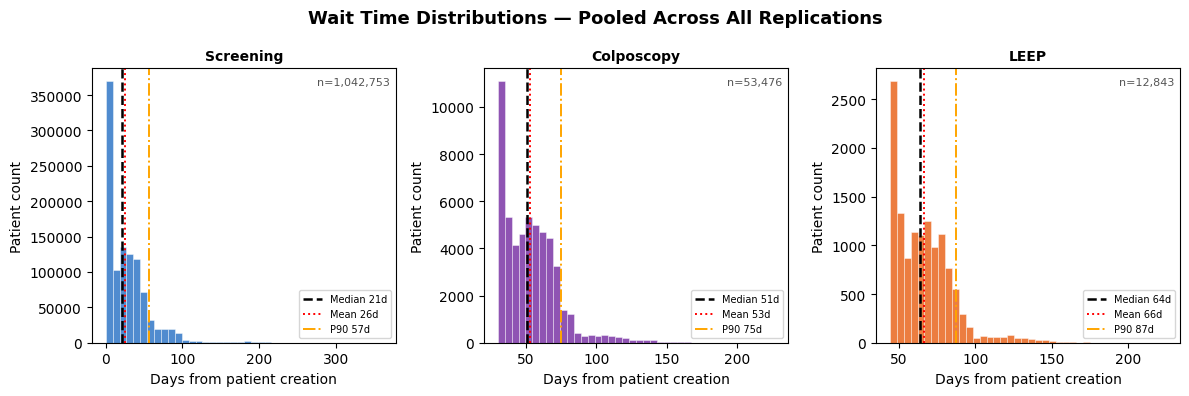

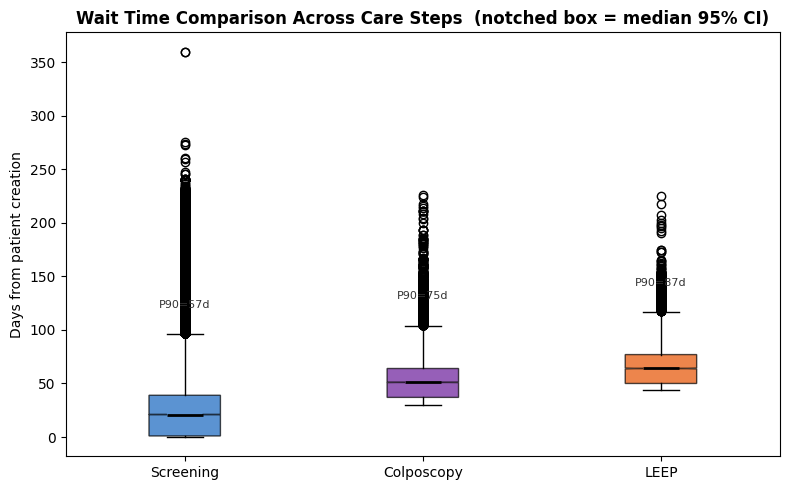


Resource                   N    Mean   Median     P75     P90     Max
--------------------------------------------------------------
Screening            1,042,753    25.7     21.0    39.0    57.0     360
Colposcopy            53,476    53.1     51.0    64.0    75.0     226
LEEP                  12,843    66.1     64.0    77.0    87.0     225


In [3]:
resources_ordered = ['screening_seen', 'colposcopy', 'leep', 'cone_biopsy', 'lung_biopsy']
resource_labels   = {
    'screening_seen': 'Screening',
    'colposcopy':     'Colposcopy',
    'leep':           'LEEP',
    'cone_biopsy':    'Cone Biopsy',
    'lung_biopsy':    'Lung Biopsy',
}
res_colors = ['#1565C0', '#6A1B9A', '#E65100', '#2E7D32', '#C62828']

present = [
    (r, resource_labels[r], c)
    for r, c in zip(resources_ordered, res_colors)
    if r in pooled_waits and len(pooled_waits[r]) > 0
]

if not present:
    print("No wait-time data. Check that patients are completing appointments.")
else:
    n_res = len(present)

    # ── Row 1: Per-resource histograms ────────────────────────────────────────
    fig, axes = plt.subplots(1, n_res, figsize=(4 * n_res, 4), sharey=False)
    if n_res == 1:
        axes = [axes]

    for ax, (res, lbl, col) in zip(axes, present):
        data = pooled_waits[res]
        ax.hist(data, bins=40, color=col, alpha=0.75, edgecolor='white', linewidth=0.4)
        med = np.median(data)
        mu  = np.mean(data)
        p90 = np.percentile(data, 90)
        ax.axvline(med, color='black',  linewidth=1.8, linestyle='--', label=f'Median {med:.0f}d')
        ax.axvline(mu,  color='red',    linewidth=1.4, linestyle=':',  label=f'Mean {mu:.0f}d')
        ax.axvline(p90, color='orange', linewidth=1.4, linestyle='-.', label=f'P90 {p90:.0f}d')
        ax.set_title(lbl, fontweight='bold', fontsize=10)
        ax.set_xlabel('Days from patient creation')
        ax.set_ylabel('Patient count')
        ax.legend(fontsize=7)
        ax.text(0.98, 0.97, f'n={len(data):,}', transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color='#555')

    plt.suptitle('Wait Time Distributions — Pooled Across All Replications',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Row 2: Side-by-side box plot ──────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(max(8, n_res * 2), 5))
    box_data = [pooled_waits[r] for r, _, _ in present]
    box_lbls = [lbl for _, lbl, _ in present]
    bp = ax2.boxplot(box_data, patch_artist=True, notch=True,
                     medianprops=dict(color='black', linewidth=2))
    for patch, (_, _, col) in zip(bp['boxes'], present):
        patch.set_facecolor(col)
        patch.set_alpha(0.70)
    ax2.set_xticklabels(box_lbls, fontsize=10)
    ax2.set_ylabel('Days from patient creation')
    ax2.set_title('Wait Time Comparison Across Care Steps  (notched box = median 95% CI)',
                  fontsize=12, fontweight='bold')
    for i, (res, _, _) in enumerate(present, 1):
        d = pooled_waits[res]
        ax2.text(i, np.percentile(d, 99) * 1.04,
                 f'P90={np.percentile(d, 90):.0f}d',
                 ha='center', fontsize=8, color='#333')
    plt.tight_layout()
    plt.show()

    # Summary stats table
    print(f"\n{'Resource':<20} {'N':>7} {'Mean':>7} {'Median':>8} {'P75':>7} {'P90':>7} {'Max':>7}")
    print("-" * 62)
    for res, lbl, _ in present:
        d = pooled_waits[res]
        print(f"{lbl:<20} {len(d):>7,} {np.mean(d):>7.1f} {np.median(d):>8.1f} "
              f"{np.percentile(d,75):>7.1f} {np.percentile(d,90):>7.1f} {max(d):>7}")

---

## Revenue Distributions

Box plots show the spread of realized and foregone revenue **across replications** — each dot is one 1-year run. Wide boxes indicate high run-to-run variability (sensitive to rare events or random patient mix). Uncomment the red reference lines once NYP Finance data is available.

> Revenue rates are placeholder CPT values — replace `cfg.PROCEDURE_REVENUE` with NYP contract rates.

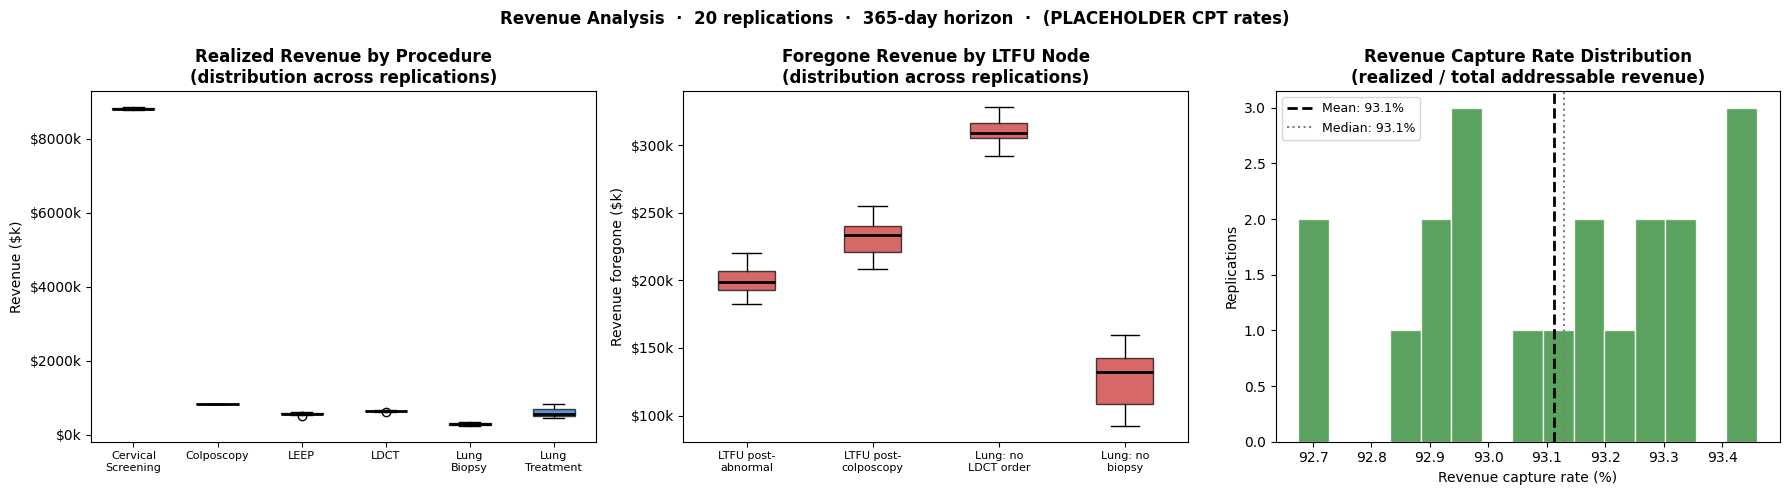


Metric                                 Mean        Std          Min          Max
--------------------------------------------------------------------------------
Realized total ($)               11,759,218    155,256   11,562,252   12,068,480
Foregone total ($)                  869,792     27,959      817,554      917,485
Capture rate (%)                       93.1       0.23         92.7         93.5


In [4]:
proc_labels = {
    'cervical_screening': 'Cervical\nScreening',
    'colposcopy':         'Colposcopy',
    'leep':               'LEEP',
    'cone_biopsy':        'Cone\nBiopsy',
    'ldct':               'LDCT',
    'lung_biopsy':        'Lung\nBiopsy',
    'lung_treatment':     'Lung\nTreatment',
}
node_labels = {
    'unscreened_cervical':          'Unscreened\n(cervical)',
    'ltfu_post_abnormal_cervical':  'LTFU post-\nabnormal',
    'ltfu_post_colposcopy':         'LTFU post-\ncolposcopy',
    'lung_no_ldct':                 'Lung: no\nLDCT order',
    'lung_no_biopsy':               'Lung: no\nbiopsy',
}

# Collect per-replication revenue
realized_by_proc = defaultdict(list)
foregone_by_node = defaultdict(list)
realized_totals  = []
foregone_totals  = []
capture_rates    = []

for m in all_metrics:
    rev = compute_revenue(m)
    realized_totals.append(rev['realized_total'])
    foregone_totals.append(rev['foregone_total'])
    total_addr = rev['realized_total'] + rev['foregone_total']
    capture_rates.append(100 * rev['realized_total'] / max(total_addr, 1))
    for proc, val in rev['realized_by_procedure'].items():
        realized_by_proc[proc].append(val)
    for node, val in rev['foregone_by_node'].items():
        foregone_by_node[node].append(val)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: Realized revenue by procedure ────────────────────────────────────
ax = axes[0]
r_keys = [k for k in proc_labels if realized_by_proc[k] and any(v > 0 for v in realized_by_proc[k])]
if r_keys:
    bp1 = ax.boxplot(
        [np.array(realized_by_proc[k]) / 1000 for k in r_keys],
        patch_artist=True, medianprops=dict(color='black', linewidth=2)
    )
    for patch in bp1['boxes']:
        patch.set_facecolor('#1565C0'); patch.set_alpha(0.70)
    ax.set_xticklabels([proc_labels[k] for k in r_keys], fontsize=8)
    ax.set_ylabel('Revenue ($k)')
    ax.set_title('Realized Revenue by Procedure\n(distribution across replications)',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
    # NYP Finance reference line — uncomment and set value:
    # ax.axhline(NYP_PROCEDURE_REVENUE_K, color='red', linestyle='--', linewidth=1.5, label='NYP ref')

# ── Panel 2: Foregone revenue by LTFU node ────────────────────────────────────
ax = axes[1]
f_keys = [k for k in node_labels if foregone_by_node[k] and any(v > 0 for v in foregone_by_node[k])]
if f_keys:
    bp2 = ax.boxplot(
        [np.array(foregone_by_node[k]) / 1000 for k in f_keys],
        patch_artist=True, medianprops=dict(color='black', linewidth=2)
    )
    for patch in bp2['boxes']:
        patch.set_facecolor('#C62828'); patch.set_alpha(0.70)
    ax.set_xticklabels([node_labels[k] for k in f_keys], fontsize=8)
    ax.set_ylabel('Revenue foregone ($k)')
    ax.set_title('Foregone Revenue by LTFU Node\n(distribution across replications)',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
else:
    ax.text(0.5, 0.5, 'No foregone revenue recorded', ha='center', va='center',
            transform=ax.transAxes, color='gray', fontsize=11)

# ── Panel 3: Capture rate distribution ───────────────────────────────────────
ax = axes[2]
ax.hist(capture_rates, bins=15, color='#388E3C', alpha=0.82, edgecolor='white')
ax.axvline(np.mean(capture_rates), color='black', linewidth=2, linestyle='--',
           label=f'Mean: {np.mean(capture_rates):.1f}%')
ax.axvline(np.median(capture_rates), color='gray', linewidth=1.5, linestyle=':',
           label=f'Median: {np.median(capture_rates):.1f}%')
# NYP Finance reference — uncomment once actual capture rate is known:
# ax.axvline(NYP_CAPTURE_RATE_PCT, color='red', linewidth=2, linestyle='-', label='NYP reference')
ax.set_xlabel('Revenue capture rate (%)')
ax.set_ylabel('Replications')
ax.set_title('Revenue Capture Rate Distribution\n(realized / total addressable revenue)',
             fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle(
    f'Revenue Analysis  ·  {N_REPS} replications  ·  {N_DAYS}-day horizon  ·  (PLACEHOLDER CPT rates)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f"\n{'Metric':<30} {'Mean':>12} {'Std':>10} {'Min':>12} {'Max':>12}")
print("-" * 80)
print(f"{'Realized total ($)':<30} {np.mean(realized_totals):>12,.0f} "
      f"{np.std(realized_totals):>10,.0f} {min(realized_totals):>12,.0f} {max(realized_totals):>12,.0f}")
print(f"{'Foregone total ($)':<30} {np.mean(foregone_totals):>12,.0f} "
      f"{np.std(foregone_totals):>10,.0f} {min(foregone_totals):>12,.0f} {max(foregone_totals):>12,.0f}")
print(f"{'Capture rate (%)':<30} {np.mean(capture_rates):>12.1f} "
      f"{np.std(capture_rates):>10.2f} {min(capture_rates):>12.1f} {max(capture_rates):>12.1f}")

---

## Screening & LTFU Rate Distributions

Each box spans the distribution of a key rate **across replications**. Tight boxes = the simulation is stable and seed-independent. Wide boxes = rare events dominate. Add horizontal reference lines from NYP HEDIS / EHR data to visually check calibration against real program performance.

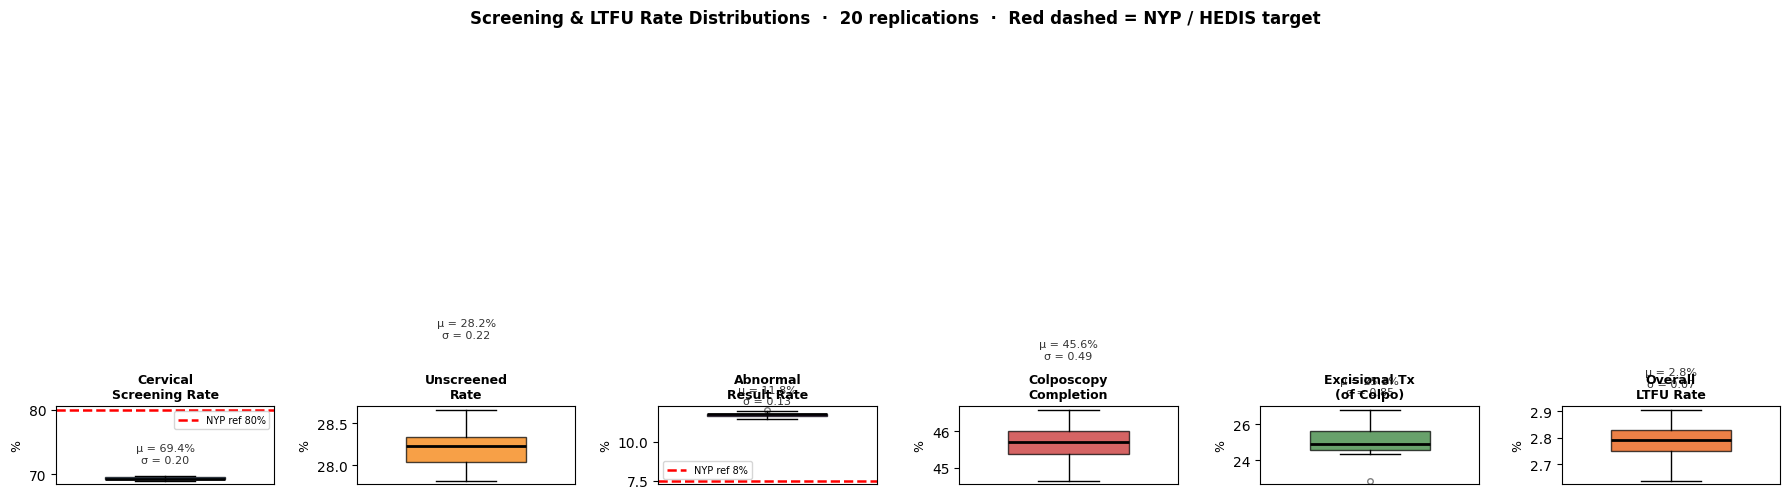


Rate                                     Mean %     Std    Min %    Max %  Literature / NYP Reference
------------------------------------------------------------------------------------------
Cervical Screening Rate                   69.41   0.195    69.03    69.71  ~80% (HEDIS CCS target)
Unscreened Rate                           28.20   0.216    27.82    28.66  TBD — NYP EHR
Abnormal Result Rate                      11.77   0.128    11.50    12.07  ~7–8% (ASCCP / SEER)
Colposcopy Completion                     45.64   0.485    44.66    46.58  ~80% (ASCCP guidance)
Excisional Tx (of Colpo)                  25.07   0.854    22.87    26.81  ~30–40% (CIN2/3 prevalence)
Overall LTFU Rate                          2.78   0.067     2.64     2.90  TBD — NYP EHR


In [5]:
rate_specs = [
    ('screening_rate_cervical_pct', 'Cervical\nScreening Rate', '#1565C0'),
    ('unscreened_pct',              'Unscreened\nRate',          '#F57C00'),
    ('abnormal_rate_cervical_pct',  'Abnormal\nResult Rate',     '#6A1B9A'),
    ('colposcopy_completion_pct',   'Colposcopy\nCompletion',    '#C62828'),
    ('treatment_completion_pct',    'Excisional Tx\n(of Colpo)', '#2E7D32'),
    ('ltfu_rate_pct',               'Overall\nLTFU Rate',        '#E65100'),
]

# NYP / literature reference values — set to None to hide the line
nyp_refs = {
    'screening_rate_cervical_pct': 80.0,    # HEDIS CCS target
    'abnormal_rate_cervical_pct':  7.5,     # ASCCP / SEER midpoint
    'unscreened_pct':              None,
    'colposcopy_completion_pct':   None,
    'treatment_completion_pct':    None,
    'ltfu_rate_pct':               None,
}

per_rep_rates = defaultdict(list)
for m in all_metrics:
    r = compute_rates(m)
    for key, _, _ in rate_specs:
        per_rep_rates[key].append(r[key])

fig, axes = plt.subplots(1, len(rate_specs), figsize=(18, 5))
for ax, (key, lbl, col) in zip(axes, rate_specs):
    data = per_rep_rates[key]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))
    bp['boxes'][0].set_facecolor(col)
    bp['boxes'][0].set_alpha(0.72)
    ax.set_ylabel('%', fontsize=9)
    ax.set_title(lbl, fontweight='bold', fontsize=9)
    ax.set_xticks([])
    ymax = max(data)
    ax.text(1, ymax * 1.03,
            f'μ = {np.mean(data):.1f}%\nσ = {np.std(data):.2f}',
            ha='center', fontsize=8, color='#333')
    ref = nyp_refs.get(key)
    if ref is not None:
        ax.axhline(ref, color='red', linestyle='--', linewidth=1.8, label=f'NYP ref {ref:.0f}%')
        ax.legend(fontsize=7)

plt.suptitle(f'Screening & LTFU Rate Distributions  ·  {N_REPS} replications  ·  Red dashed = NYP / HEDIS target',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n{'Rate':<38} {'Mean %':>8} {'Std':>7} {'Min %':>8} {'Max %':>8}  {'Literature / NYP Reference'}")
print("-" * 90)
lit_refs = {
    'screening_rate_cervical_pct': '~80% (HEDIS CCS target)',
    'unscreened_pct':              'TBD — NYP EHR',
    'abnormal_rate_cervical_pct':  '~7–8% (ASCCP / SEER)',
    'colposcopy_completion_pct':   '~80% (ASCCP guidance)',
    'treatment_completion_pct':    '~30–40% (CIN2/3 prevalence)',
    'ltfu_rate_pct':               'TBD — NYP EHR',
}
for key, lbl, _ in rate_specs:
    d = per_rep_rates[key]
    clean_lbl = lbl.replace('\n', ' ')
    print(f"{clean_lbl:<38} {np.mean(d):>8.2f} {np.std(d):>7.3f} "
          f"{min(d):>8.2f} {max(d):>8.2f}  {lit_refs.get(key, 'TBD')}")

---

## Cervical Result Distribution — Observed vs. Expected

Bars show the **mean observed rate** across all replications; error bars show ±1 standard deviation. Light bars show the expected probability from `config.py`. Close agreement confirms the stochastic sampling is unbiased relative to the input tables. Divergence points to a bug or a misspecified parameter.

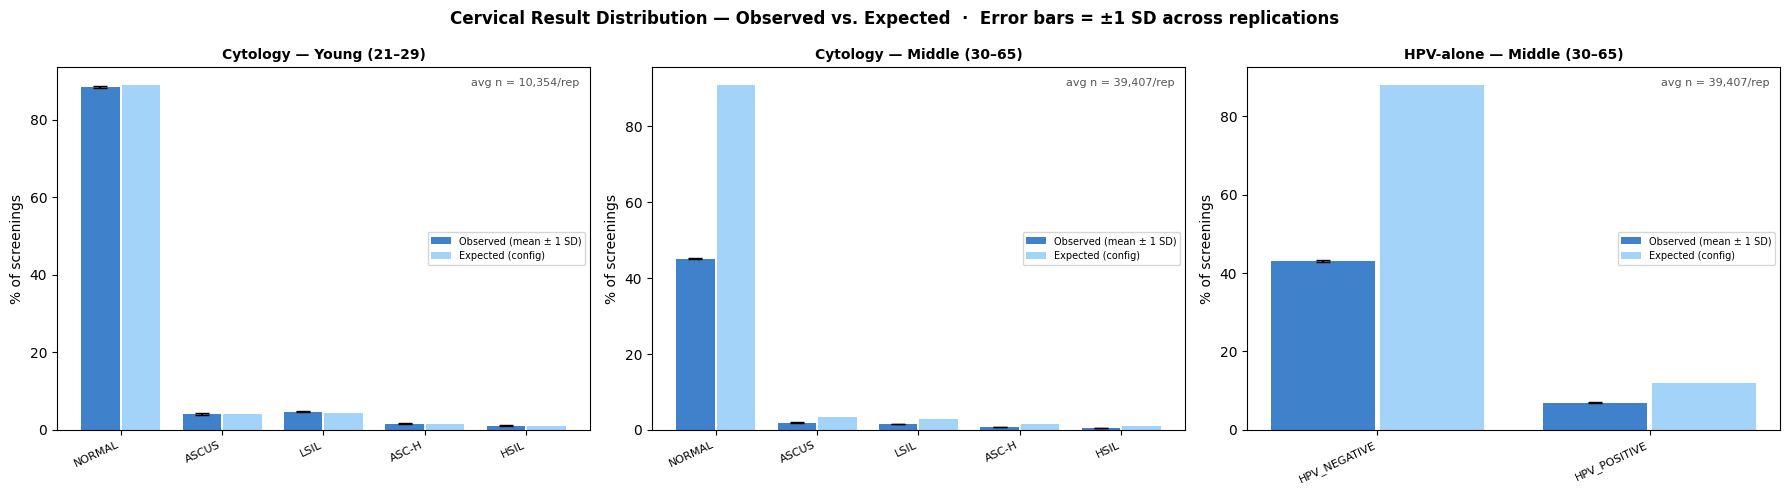

In [6]:
cyto_cats = ['NORMAL', 'ASCUS', 'LSIL', 'ASC-H', 'HSIL']
hpv_cats  = ['HPV_NEGATIVE', 'HPV_POSITIVE']

strata_def = [
    ('young',  'Cytology — Young (21–29)',   'young',           cyto_cats),
    ('middle', 'Cytology — Middle (30–65)',  'middle_cytology', cyto_cats),
    ('middle', 'HPV-alone — Middle (30–65)', 'middle_hpv',      hpv_cats),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (stratum_key, title, cfg_key, cats) in zip(axes, strata_def):
    # Per-replication observed rates
    obs_rates = defaultdict(list)
    for m in all_metrics:
        sub   = m['cervical_by_age_stratum'].get(stratum_key, {})
        total = max(sum(sub.values()), 1)
        for cat in cats:
            obs_rates[cat].append(sub.get(cat, 0) / total * 100)

    means = [np.mean(obs_rates[c]) for c in cats]
    stds  = [np.std(obs_rates[c])  for c in cats]
    exps  = [cfg.CERVICAL_RESULT_PROBS.get(cfg_key, {}).get(c, 0) * 100 for c in cats]

    x = np.arange(len(cats))
    ax.bar(x - 0.2, means, 0.38, yerr=stds, capsize=5,
           color='#1565C0', alpha=0.82, label='Observed (mean ± 1 SD)')
    ax.bar(x + 0.2, exps,  0.38,
           color='#90CAF9', alpha=0.82, label='Expected (config)')
    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('% of screenings')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    n_avg = int(np.mean([
        sum(m['cervical_by_age_stratum'].get(stratum_key, {}).values())
        for m in all_metrics
    ]))
    ax.text(0.98, 0.97, f'avg n = {n_avg:,}/rep', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='#555')

plt.suptitle(
    'Cervical Result Distribution — Observed vs. Expected  ·  Error bars = ±1 SD across replications',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

---

## Lung-RADS Distribution — Observed vs. Expected

RADS category mix from all completed LDCTs, pooled across replications, compared to the input probability table in `config.py`. The right panel focuses on the **RADS 4 rate** (the biopsy-trigger rate) — the most clinically consequential metric, and the one most directly comparable to ACR national benchmarks.

> Replace `cfg.LUNG_RADS_PROBS` with NYP LDCT program data once available. ACR national data: RADS 1–2 ≈ 70–80% of screens; RADS 4A/4X ≈ 5–10%.

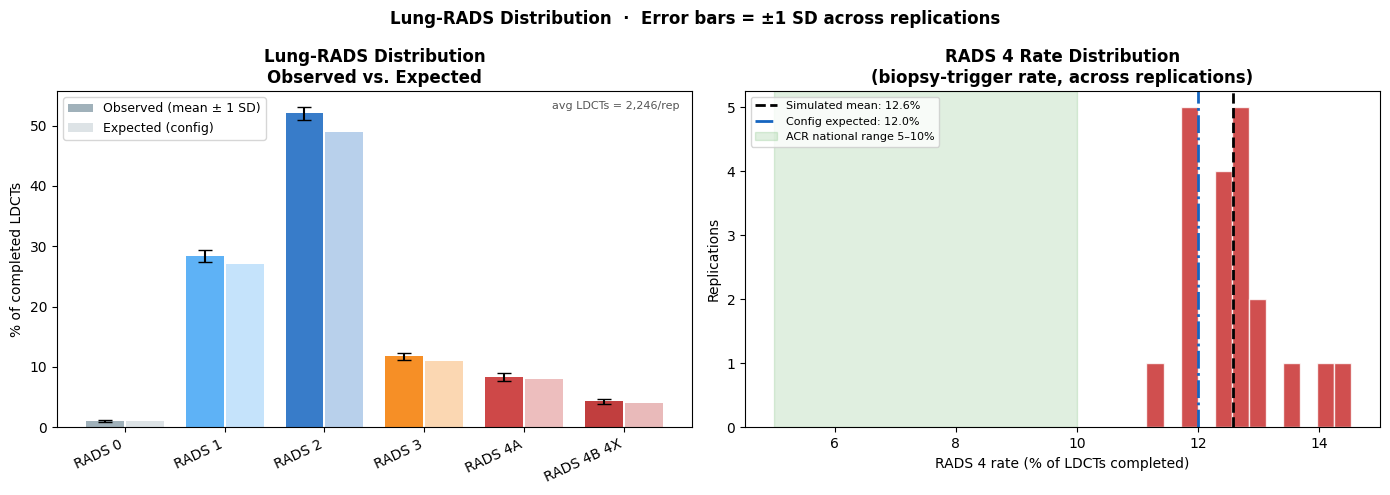


RADS Category   Obs Mean %   Obs SD  Expected %   Δ (obs−exp)
------------------------------------------------------------
RADS_0                 1.0     0.17         1.0         +0.01
RADS_1                28.4     1.04        27.0         +1.38
RADS_2                52.0     1.04        49.0         +3.02
RADS_3                11.7     0.63        11.0         +0.75
RADS_4A                8.3     0.68         8.0         +0.29
RADS_4B_4X             4.3     0.35         4.0         +0.29

RADS 4 total  mean=12.6%  std=0.78%  expected=12.0%  ACR range=5–10%


In [7]:
rads_cats   = ['RADS_0', 'RADS_1', 'RADS_2', 'RADS_3', 'RADS_4A', 'RADS_4B_4X']
rads_colors = ['#90A4AE', '#42A5F5', '#1565C0', '#F57C00', '#C62828', '#B71C1C']

# Per-replication observed rates
obs_rads = defaultdict(list)
for m in all_metrics:
    total_ldct = max(m['lung_ldct_completed'], 1)
    for cat in rads_cats:
        obs_rads[cat].append(m['lung_rads_distribution'].get(cat, 0) / total_ldct * 100)

obs_means = [np.mean(obs_rads[c]) for c in rads_cats]
obs_stds  = [np.std(obs_rads[c])  for c in rads_cats]
exp_vals  = [cfg.LUNG_RADS_PROBS.get(c, 0) * 100 for c in rads_cats]

# RADS 4 total rate per rep (used in both panels)
rads4_rates = [obs_rads['RADS_4A'][i] + obs_rads['RADS_4B_4X'][i] for i in range(N_REPS)]
exp_rads4   = (cfg.LUNG_RADS_PROBS['RADS_4A'] + cfg.LUNG_RADS_PROBS['RADS_4B_4X']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: Observed vs expected by RADS category ───────────────────────────
ax = axes[0]
x = np.arange(len(rads_cats))
ax.bar(x - 0.2, obs_means, 0.38, yerr=obs_stds, capsize=5,
       color=rads_colors, alpha=0.85, label='Observed (mean ± 1 SD)')
ax.bar(x + 0.2, exp_vals,  0.38,
       color=[(*[c/255 for c in rgb], 0.30)
              for rgb in [(144,164,174),(66,165,245),(21,101,192),(245,124,0),(198,40,40),(183,28,28)]],
       label='Expected (config)')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', ' ') for c in rads_cats], rotation=25, ha='right')
ax.set_ylabel('% of completed LDCTs')
ax.set_title('Lung-RADS Distribution\nObserved vs. Expected', fontweight='bold')
ax.legend(fontsize=9)
n_avg_ldct = int(np.mean([m['lung_ldct_completed'] for m in all_metrics]))
ax.text(0.98, 0.97, f'avg LDCTs = {n_avg_ldct:,}/rep', transform=ax.transAxes,
        ha='right', va='top', fontsize=8, color='#555')

# ── Panel 2: RADS 4 rate distribution (biopsy trigger) ───────────────────────
ax2 = axes[1]
ax2.hist(rads4_rates, bins=12, color='#C62828', alpha=0.82, edgecolor='white')
ax2.axvline(np.mean(rads4_rates), color='black', linewidth=2.0, linestyle='--',
            label=f'Simulated mean: {np.mean(rads4_rates):.1f}%')
ax2.axvline(exp_rads4, color='#1565C0', linewidth=2.0, linestyle='-.',
            label=f'Config expected: {exp_rads4:.1f}%')
ax2.axvspan(5, 10, alpha=0.12, color='green', label='ACR national range 5–10%')
ax2.set_xlabel('RADS 4 rate (% of LDCTs completed)')
ax2.set_ylabel('Replications')
ax2.set_title('RADS 4 Rate Distribution\n(biopsy-trigger rate, across replications)',
              fontweight='bold')
ax2.legend(fontsize=8)

plt.suptitle('Lung-RADS Distribution  ·  Error bars = ±1 SD across replications',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n{'RADS Category':<14} {'Obs Mean %':>11} {'Obs SD':>8} {'Expected %':>11}  {'Δ (obs−exp)':>12}")
print("-" * 60)
for cat, omean, ostd, exp in zip(rads_cats, obs_means, obs_stds, exp_vals):
    print(f"{cat:<14} {omean:>11.1f} {ostd:>8.2f} {exp:>11.1f}  {omean - exp:>+12.2f}")
print(f"\nRADS 4 total  mean={np.mean(rads4_rates):.1f}%  std={np.std(rads4_rates):.2f}%  "
      f"expected={exp_rads4:.1f}%  ACR range=5–10%")

---

## Summary Validation Table

All key metrics in one place — simulation mean ± standard deviation alongside the NYP / literature benchmark. Fill in the **NYP Reference** column once EHR and Finance data are extracted. Values that diverge from the literature by more than ~10 percentage points should be re-examined in `config.py`.

In [8]:
def _rep_vals(key):
    return [m[key] for m in all_metrics]

def _fn_vals(fn):
    return [fn(m) for m in all_metrics]

def _rate_vals(key):
    return [compute_rates(m)[key] for m in all_metrics]

rows = [
    # (section, metric, values_list, nyp_ref, unit)
    ("Volume",
     "Patients simulated / year",
     _rep_vals('n_patients'),
     "~73,000  (200/day × 365)",
     "count"),

    ("Volume",
     "Eligible for cervical screening",
     _fn_vals(lambda m: m['n_eligible'].get('cervical', 0)),
     "TBD — NYP EHR",
     "count"),

    ("Volume",
     "Eligible for lung LDCT",
     _rep_vals('lung_eligible'),
     "TBD — NYP EHR",
     "count"),

    ("Cervical Screening",
     "Screening rate",
     _rate_vals('screening_rate_cervical_pct'),
     "~80%  (HEDIS CCS)",
     "%"),

    ("Cervical Screening",
     "Abnormal result rate",
     _rate_vals('abnormal_rate_cervical_pct'),
     "~7–8%  (ASCCP / SEER)",
     "%"),

    ("Cervical Screening",
     "Colposcopy completion (of abnormals)",
     _rate_vals('colposcopy_completion_pct'),
     "~80%  (ASCCP guidance)",
     "%"),

    ("Cervical Screening",
     "Excisional tx rate (of colposcopies)",
     _rate_vals('treatment_completion_pct'),
     "~30–40%  (CIN2/3 prevalence)",
     "%"),

    ("LTFU",
     "Overall LTFU rate",
     _rate_vals('ltfu_rate_pct'),
     "TBD — NYP EHR",
     "%"),

    ("LTFU",
     "Post-abnormal LTFU (count/yr)",
     _rep_vals('ltfu_post_abnormal'),
     "TBD — NYP EHR",
     "count"),

    ("LTFU",
     "Post-colposcopy LTFU (count/yr)",
     _rep_vals('ltfu_post_colposcopy'),
     "TBD — NYP EHR",
     "count"),

    ("Lung LDCT",
     "LDCTs completed / year",
     _rep_vals('lung_ldct_completed'),
     "TBD — NYP LDCT program",
     "count"),

    ("Lung LDCT",
     "RADS 4 rate (biopsy trigger)",
     rads4_rates,
     "5–10%  (ACR national)",
     "%"),

    ("Lung LDCT",
     "Malignancy confirmed / year",
     _rep_vals('lung_malignancy_confirmed'),
     "TBD — NYP Cancer Registry",
     "count"),

    ("Revenue (placeholder CPT rates)",
     "Realized revenue / year ($)",
     realized_totals,
     "TBD — NYP Finance",
     "$"),

    ("Revenue (placeholder CPT rates)",
     "Foregone revenue / year ($)",
     foregone_totals,
     "TBD — NYP Finance",
     "$"),

    ("Revenue (placeholder CPT rates)",
     "Revenue capture rate",
     capture_rates,
     "TBD — NYP Finance",
     "%"),
]

# ── Print table ────────────────────────────────────────────────────────────────
col_w = [30, 42, 13, 11, 10, 11]
header = (f"{'Section':<{col_w[0]}} {'Metric':<{col_w[1]}} "
          f"{'Mean':>{col_w[2]}} {'±SD':>{col_w[3]}} {'Min':>{col_w[4]}} {'Max':>{col_w[5]}}  NYP Reference")
print(header)
print("=" * (sum(col_w) + 15))

last_sec = None
for section, metric, vals, nyp_ref, unit in rows:
    if section != last_sec:
        print(f"\n  [{section}]")
        last_sec = section
    mu  = np.mean(vals)
    sd  = np.std(vals)
    lo  = min(vals)
    hi  = max(vals)
    if unit == "$":
        fmt = lambda v: f"${v:,.0f}"
    elif unit == "%":
        fmt = lambda v: f"{v:.1f}%"
    else:
        fmt = lambda v: f"{v:,.0f}"
    print(f"    {metric:<{col_w[1]}} {fmt(mu):>{col_w[2]}} {('±'+fmt(sd).lstrip('$')):>{col_w[3]}} "
          f"{fmt(lo):>{col_w[4]}} {fmt(hi):>{col_w[5]}}  {nyp_ref}")

print("\n" + "=" * (sum(col_w) + 15))
print(f"N replications: {N_REPS}   Horizon: {N_DAYS} days")
print("NYP Reference = TBD: fill in from EHR / Finance exports before validation sign-off.")
print("Revenue figures use PLACEHOLDER CPT rates — replace cfg.PROCEDURE_REVENUE.")

Section                        Metric                                              Mean         ±SD        Min         Max  NYP Reference

  [Volume]
    Patients simulated / year                         71,692         ±62     71,562      71,794  ~73,000  (200/day × 365)
    Eligible for cervical screening                   49,762        ±133     49,533      50,025  TBD — NYP EHR
    Eligible for lung LDCT                             3,890         ±78      3,712       4,030  TBD — NYP EHR

  [Cervical Screening]
    Screening rate                                     69.4%       ±0.2%      69.0%       69.7%  ~80%  (HEDIS CCS)
    Abnormal result rate                               11.8%       ±0.1%      11.5%       12.1%  ~7–8%  (ASCCP / SEER)
    Colposcopy completion (of abnormals)               45.6%       ±0.5%      44.7%       46.6%  ~80%  (ASCCP guidance)
    Excisional tx rate (of colposcopies)               25.1%       ±0.9%      22.9%       26.8%  ~30–40%  (CIN2/3 prevalence)

 